Baseline model AUC: 0.5000
Advanced model AUC: 0.9635

Classification report for XGBoost:

              precision    recall  f1-score   support

         0.0       0.95      0.92      0.94     30650
         1.0       0.85      0.91      0.88     14955

    accuracy                           0.92     45605
   macro avg       0.90      0.91      0.91     45605
weighted avg       0.92      0.92      0.92     45605



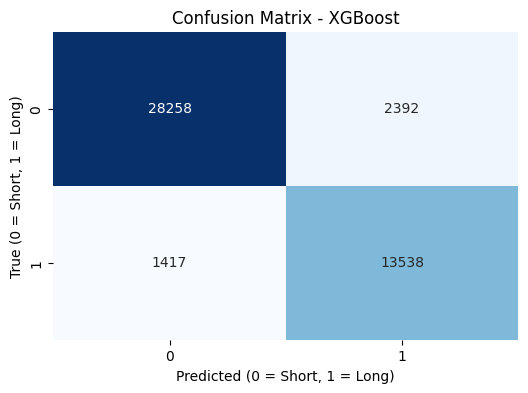

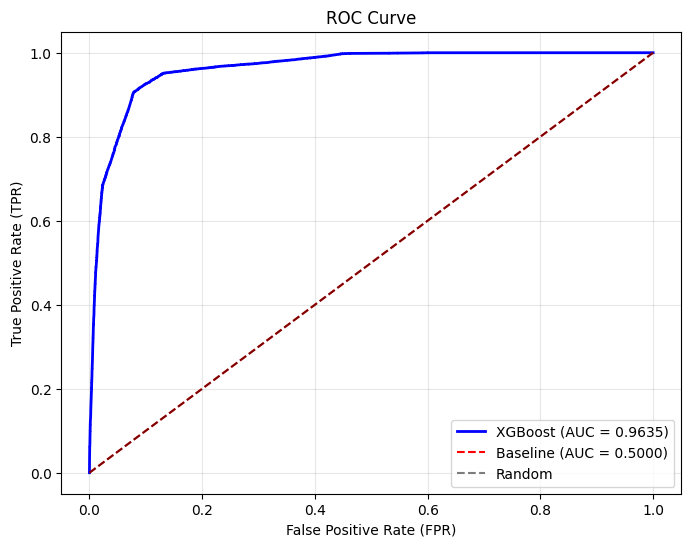

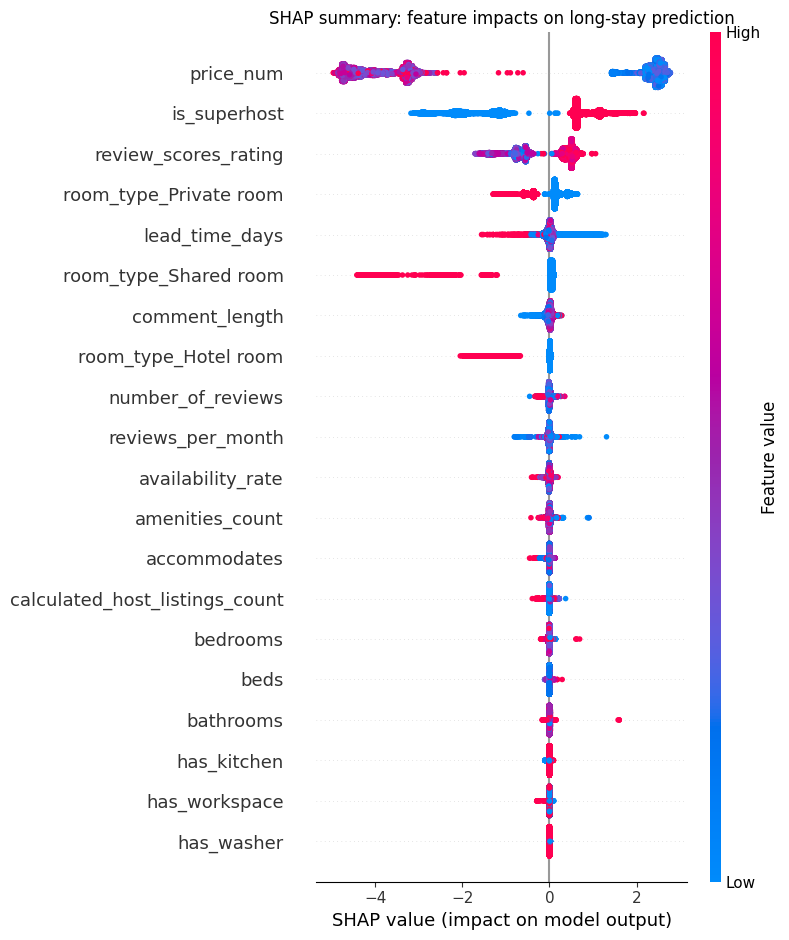

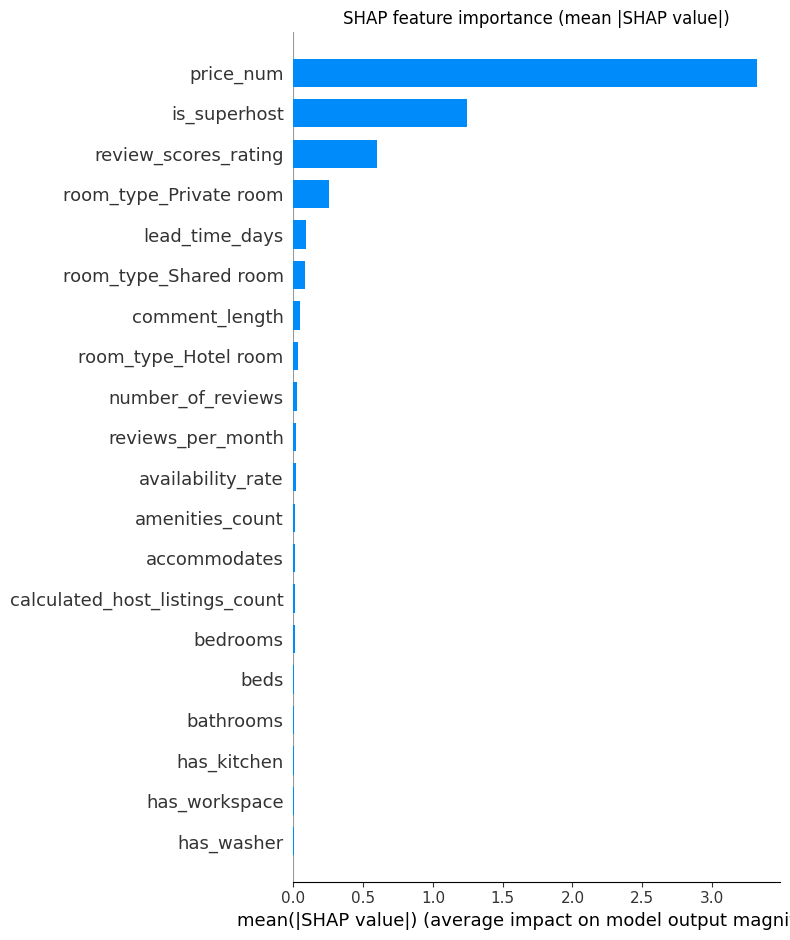

Models and feature names saved to ../src/models/


In [2]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import shap 

os.makedirs('../src/models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

df = pd.read_csv('../data/processed/processed_data.csv').astype(float)
X = df.drop('is_long_stay', axis=1)
y = df['is_long_stay']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_baseline = DummyClassifier(strategy='prior')
model_baseline.fit(X_train, y_train)

model_advanced = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)
model_advanced.fit(X_train, y_train)

base_probs = model_baseline.predict_proba(X_test)[:, 1]
adv_probs = model_advanced.predict_proba(X_test)[:, 1]
adv_preds = model_advanced.predict(X_test)

base_auc = roc_auc_score(y_test, base_probs)
adv_auc = roc_auc_score(y_test, adv_probs)

print(f"Baseline model AUC: {base_auc:.4f}")
print(f"Advanced model AUC: {adv_auc:.4f}\n")

report = classification_report(y_test, adv_preds)
print("Classification report for XGBoost:\n")
print(report)

with open('../results/classification_report.txt', 'w') as f:
    f.write(report)

cm = confusion_matrix(y_test, adv_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted (0 = Short, 1 = Long)')
plt.ylabel('True (0 = Short, 1 = Long)')
plt.savefig('../results/confusion_matrix.png', bbox_inches='tight')
plt.show()

fpr_adv, tpr_adv, _ = roc_curve(y_test, adv_probs)
fpr_base, tpr_base, _ = roc_curve(y_test, base_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr_adv, tpr_adv, label=f'XGBoost (AUC = {adv_auc:.4f})', color='blue', linewidth=2)
plt.plot(fpr_base, tpr_base, label=f'Baseline (AUC = {base_auc:.4f})', color='red', linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', label='Random', alpha=0.5)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('../results/roc_curve.png', bbox_inches='tight')
plt.show()

explainer = shap.TreeExplainer(model_advanced)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP summary: feature impacts on long-stay prediction')
plt.tight_layout()
plt.savefig('../results/shap_summary_dot.png', bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP feature importance (mean |SHAP value|)')
plt.tight_layout()
plt.savefig('../results/shap_summary_bar.png', bbox_inches='tight')
plt.show()

joblib.dump(model_baseline, '../src/models/model_baseline.joblib')
joblib.dump(model_advanced, '../src/models/model_advanced.joblib')
joblib.dump(X.columns.tolist(), '../src/models/model_features.joblib')

print("Models and feature names saved to ../src/models/")